# Interpolation kinds: what each one does between and beyond the data

`interp.interpolant` builds a curve through tabulated data, and the kind decides what happens
between the sites and beyond them. This notebook puts all ten kinds side by side on two data
sets. The first is Runge's function sampled at 11 points, smooth but hard for polynomials. The
second is a staircase of steps and plateaus, the shape a measured map often has. Each kind is
checked against the SciPy object it reproduces, or the paper or CasADi where SciPy has no
counterpart. Then the kinds are measured on the things that differ between them:

- overshoot, monotonicity and smoothness;
- the five ways of continuing past the last site;
- derivatives up to the spline's degree;
- integrals, and the inverse of a monotone curve.

Every evaluation runs through generated C, not through a Python evaluation.

| Scaly feature | Where |
| --- | --- |
| `interp.interpolant(x, y, kind=...)`, all ten kinds | every section |
| `extrap="linear"`, `"clamp"`, `"extend"`, `"periodic"`, `"fill"` | beyond the data |
| reverse mode through a batch, `BSpline.derivative` | derivatives up to the degree |
| `BSpline.integrate` with numbers and with an `Expr` limit | integrals |
| `BSpline.inverse` and its derivative | a thermistor read backwards |
| `write_module` | the generated C |

In [1]:
import sys
from pathlib import Path

import casadi as ca
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate as si

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import interp
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "interp" / "interpolation_kinds"


def evaluate(f, x, orders=0, label="f"):
  """``f`` at the points ``x`` through generated code, one batch Function; ``orders`` (a number or a
  tuple) picks the derivatives, each by reverse mode through the one before it."""
  wanted = (orders,) if np.ndim(orders) == 0 else tuple(orders)

  @sc.function(sc.L("x", x.shape), name=f"kinds_{label}_{x.size}")
  def batch(X):
    y, outs = f(X), []
    for nu in range(max(wanted) + 1):
      outs += [y] if nu in wanted else []
      y = sc.gradient(y.sum(), X) if nu < max(wanted) else y
    return tuple(outs) if len(outs) > 1 else outs[0]

  out = batch(x)
  return [np.asarray(o) for o in out] if len(wanted) > 1 else np.asarray(out)

## Two data sets

Runge's function $1/(1 + 25 x^2)$ at 11 equally spaced sites in $[-1, 1]$ is the textbook case
where a smooth interpolant rings. The staircase holds each value over several sites and then
climbs steeply, so a method that assumes smoothness overshoots the plateaus.

Every kind is evaluated at 1 999 points across each data set and compared with its reference:

- SciPy's `RegularGridInterpolator(method="nearest")` for `nearest`;
- a `searchsorted` for `zoh`;
- `np.interp` for `linear`;
- `CubicSpline` (not-a-knot) for `cubic`;
- `make_interp_spline(k=5)` for `spline` of degree 5;
- `PchipInterpolator` for `pchip`;
- `Akima1DInterpolator` for `akima` and `makima`;
- Steffen's (1990) slope formulas in a `CubicHermiteSpline` for `steffen`;
- CasADi's own `smooth_linear` for `smooth_linear`, the one kind neither SciPy nor a paper
  defines.

The grid avoids the points exactly midway between sites, where `nearest` breaks its tie by
rounding.

In [2]:
runge_x = np.linspace(-1.0, 1.0, 11)
runge_y = 1.0 / (1.0 + 25.0 * runge_x**2)
steps_x = np.arange(11.0)
steps_y = np.array([0.0, 0.0, 0.0, 0.2, 1.8, 2.0, 2.0, 2.0, 2.4, 4.0, 4.0])
DATA = {"runge": (runge_x, runge_y), "steps": (steps_x, steps_y)}
DENSE = {name: np.linspace(x[0], x[-1], 1999) for name, (x, _) in DATA.items()}  # no point exactly midway between sites


def steffen_slopes(x, y):
  """Steffen (1990), eqs. 11 and 26-27: the reference, one site at a time."""
  h, s = np.diff(x), np.diff(y) / np.diff(x)
  d = np.zeros(x.size)
  for i in range(1, x.size - 1):
    p = (s[i - 1] * h[i] + s[i] * h[i - 1]) / (h[i - 1] + h[i])
    d[i] = (np.sign(s[i - 1]) + np.sign(s[i])) * min(abs(s[i - 1]), abs(s[i]), 0.5 * abs(p))
  for i, (h0, h1, s0, s1) in ((0, (h[0], h[1], s[0], s[1])), (x.size - 1, (h[-1], h[-2], s[-1], s[-2]))):
    p = s0 * (1 + h0 / (h0 + h1)) - s1 * h0 / (h0 + h1)
    d[i] = 0.0 if p * s0 <= 0 else 2 * s0 if abs(p) > 2 * abs(s0) else p
  return d


def casadi_smooth_linear(x, y):
  table = ca.interpolant("sl", "bspline", [list(x)], list(y), {"algorithm": "smooth_linear"})
  return lambda q: np.asarray(table.map(q.size)(q[None, :])).reshape(-1)


REFERENCES = {  # the kind, its extra arguments, and SciPy's (or the paper's, or CasADi's) version
  "nearest": ({}, lambda x, y: lambda q: si.RegularGridInterpolator((x,), y, method="nearest")(q[:, None])),
  "zoh": ({}, lambda x, y: lambda q: y[np.searchsorted(x, q, side="right") - 1]),
  "linear": ({}, lambda x, y: lambda q: np.interp(q, x, y)),
  "cubic": ({}, si.CubicSpline),
  "spline": ({"degree": 5}, lambda x, y: si.make_interp_spline(x, y, k=5)),
  "pchip": ({}, si.PchipInterpolator),
  "akima": ({}, si.Akima1DInterpolator),
  "makima": ({}, lambda x, y: si.Akima1DInterpolator(x, y, method="makima")),
  "steffen": ({}, lambda x, y: si.CubicHermiteSpline(x, y, steffen_slopes(x, y))),
  "smooth_linear": ({}, casadi_smooth_linear),
}
fits = {(name, kind): interp.interpolant(x, y, kind=kind, **kw) for name, (x, y) in DATA.items() for kind, (kw, _) in REFERENCES.items()}
values, derivatives, breaks = {}, {}, {}
for (name, kind), f in fits.items():
  edges = f.axes[0].edges  # the partition: where the pieces meet
  breaks[name, kind] = edges[(edges > DATA[name][0][0]) & (edges < DATA[name][0][-1])]
  points = np.concatenate([DENSE[name], breaks[name, kind] - 1e-9, breaks[name, kind] + 1e-9])
  out = evaluate(f, points, orders=(0, 1, 2, 3, 4), label=f"{name}_{kind}")
  values[name, kind] = out[0][: DENSE[name].size]
  derivatives[name, kind] = [o[DENSE[name].size :] for o in out]  # a hair left of each break, then a hair right
vs_reference = {}
for (name, kind), v in values.items():
  x, y = DATA[name]
  q = DENSE[name]
  if kind == "zoh":
    q = q[:-1]  # the last site holds on to the next spacing in both, but SciPy has no such rule to compare
  vs_reference[name, kind] = float(np.abs(v[: q.size] - REFERENCES[kind][1](x, y)(q)).max())
print(f"{'kind':14s} {'runge':>9s} {'steps':>9s}")
for kind in REFERENCES:
  print(f"{kind:14s} {vs_reference['runge', kind]:9.1e} {vs_reference['steps', kind]:9.1e}")

kind               runge     steps
nearest          0.0e+00   0.0e+00
zoh              0.0e+00   0.0e+00
linear           2.2e-16   4.4e-16
cubic            5.6e-16   1.8e-15
spline           3.3e-16   1.8e-15
pchip            2.2e-16   1.3e-15
akima            3.3e-16   1.3e-15
makima           2.2e-16   1.8e-15
steffen          2.2e-16   1.3e-15
smooth_linear    3.3e-16   1.3e-15


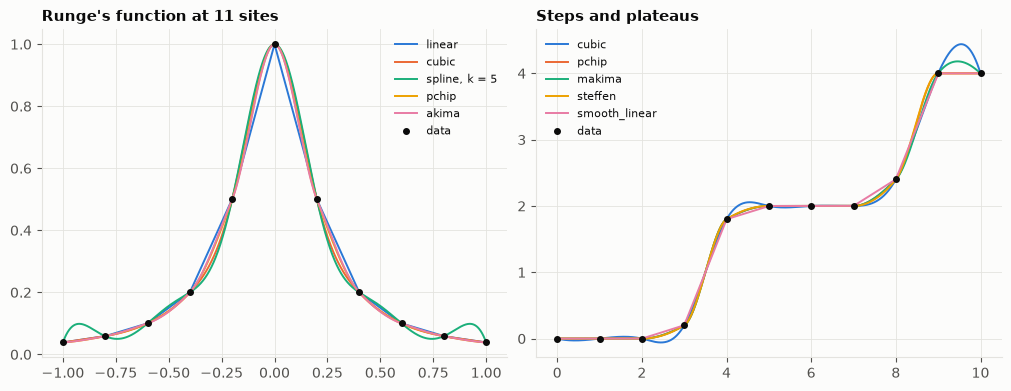

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
groups = {"runge": ("linear", "cubic", "spline", "pchip", "akima"), "steps": ("cubic", "pchip", "makima", "steffen", "smooth_linear")}
for ax, (name, kinds) in zip(axes, groups.items(), strict=True):
  x, y = DATA[name]
  for kind in kinds:
    ax.plot(DENSE[name], values[name, kind], lw=1.4, label=kind if kind != "spline" else "spline, k = 5")
  ax.plot(x, y, "o", color=plotstyle.TEXT, ms=4, label="data", zorder=5)
  ax.legend(fontsize=8, loc="upper left" if name == "steps" else "upper right")
axes[0].set_title("Runge's function at 11 sites")
axes[1].set_title("Steps and plateaus")
plt.show()

## Overshoot, monotonicity and continuity

The staircase separates the kinds. The table below measures each one on it:

- **overshoot**: how far the curve leaves the range of the two data values around it;
- **monotone**: whether it keeps the data's order (they never decrease);
- **smoothness**: the jumps of the value and of its first four derivatives across the joins of
  the pieces, taken a hair (10⁻⁹) either side. A jump of order 10⁻⁹ is the slope times that
  hair: continuous.

In [4]:
def jumps(name, kind):
  """The largest jump of the value and of each derivative up to the fourth where the pieces meet:
  the value a hair to the right of each break against the value a hair to its left."""
  n = breaks[name, kind].size
  return [float(np.abs(d[:n] - d[n:]).max()) for d in derivatives[name, kind]]


shape_rows = []
x, y = DATA["steps"]
for kind in REFERENCES:
  v = values["steps", kind]
  cell = np.clip(np.searchsorted(x, DENSE["steps"], side="right") - 1, 0, x.size - 2)
  above = v - np.maximum(y[cell], y[cell + 1])
  below = np.minimum(y[cell], y[cell + 1]) - v
  j = jumps("steps", kind)
  smooth = next((k - 1 for k in range(5) if j[k] > 1e-6), 4)
  shape_rows.append((kind, max(above.max(), below.max(), 0.0), bool(np.all(np.diff(v) >= -1e-12)), smooth, j))
print(f"{'kind':14s} {'overshoot':>10s} {'monotone':>9s}  C^k   jumps of f to its 4th derivative")
for kind, over, mono, smooth, j in shape_rows:
  print(f"{kind:14s} {over:10.3f} {str(mono):>9s}  C{smooth if smooth >= 0 else '-1'}   " + "  ".join(f"{a:8.1e}" for a in j))

kind            overshoot  monotone  C^k   jumps of f to its 4th derivative
nearest             0.000      True  C-1    1.6e+00   0.0e+00   0.0e+00   0.0e+00   0.0e+00
zoh                 0.000      True  C-1    1.6e+00   0.0e+00   0.0e+00   0.0e+00   0.0e+00
linear              0.000      True  C0    2.0e-09   1.6e+00   0.0e+00   0.0e+00   0.0e+00
cubic               0.440     False  C2    2.9e-09   5.9e-09   7.6e-09   9.3e+00   0.0e+00
spline              0.659     False  C4    3.6e-09   4.6e-09   1.1e-08   3.3e-08   2.9e-08
pchip               0.000      True  C1    1.3e-09   8.3e-09   8.3e+00   1.5e+01   0.0e+00
akima               0.215     False  C1    1.8e-09   7.7e-09   7.0e+00   1.5e+01   0.0e+00
makima              0.181     False  C1    1.7e-09   7.7e-09   7.2e+00   1.5e+01   0.0e+00
steffen             0.000      True  C1    1.6e-09   8.0e-09   8.0e+00   1.4e+01   0.0e+00
smooth_linear       0.024      True  C2    3.2e-09   3.2e-08   1.6e-07   3.2e+02   0.0e+00


The classes come out as the theory says:

- `nearest` and `zoh` are steps;
- `linear` is continuous with kinked slopes;
- the four shape-preserving kinds (`pchip`, `akima`, `makima`, `steffen`) are C¹, their
  curvature jumping at every site;
- the cubic spline is C² and the quintic C⁴.

Smoothness costs shape: the C² cubic overshoots a plateau by 0.44 and the quintic by 0.66, the
ringing on the left of the figure. Akima's weights damp it to 0.22, and the modified Akima to
0.18. PCHIP and Steffen neither overshoot nor break monotonicity, since each slope is limited by
its neighbouring secants. Steffen's limiter also keeps every extremum at a site.

`smooth_linear` is monotone and C², but it does not pass through the data. It rounds each corner
within a tenth of the spacing and misses the data there by up to 0.024.

## Beyond the data

Past the last site, `extrap` decides:

- `"linear"`, the default from degree 1 up: along the tangent at the end, so the value and
  the slope are continuous there;
- `"clamp"`: holds the end value;
- `"extend"`: continues the end polynomial, SciPy's `extrapolate=True`;
- `"periodic"`: wraps the point into the base interval;
- `"fill"`: returns a constant.

CasADi's `bspline` interpolant has no choice: it is zero outside its grid.

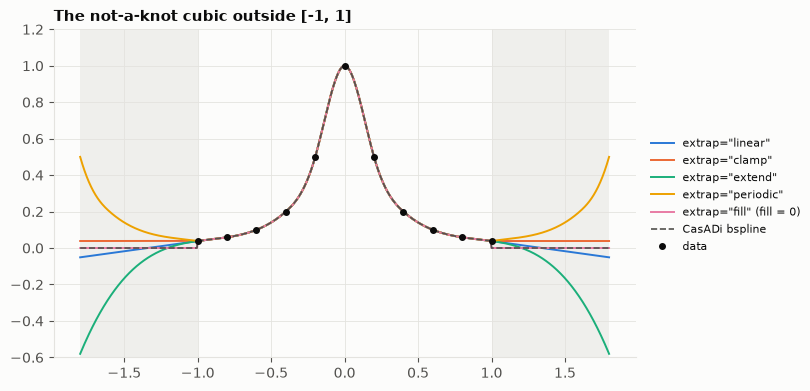

extend against SciPy's own extrapolation: 1.8e-15; CasADi's bspline outside: max |value| 0.0e+00


In [5]:
outside = np.linspace(-1.8, 1.8, 721)
modes = ("linear", "clamp", "extend", "periodic", "fill")
extrapolated = {
  mode: evaluate(interp.interpolant(runge_x, runge_y, kind="cubic", extrap=mode, fill=0.0), outside, label=f"extrap_{mode}") for mode in modes
}
bspline = ca.interpolant("bs", "bspline", [list(runge_x)], list(runge_y))
casadi_outside = np.asarray(bspline.map(outside.size)(outside[None, :])).reshape(-1)
inside = np.abs(outside) <= 1.0
reference = si.CubicSpline(runge_x, runge_y)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.axvspan(-1.8, -1.0, color=plotstyle.GRID, alpha=0.5, lw=0)
ax.axvspan(1.0, 1.8, color=plotstyle.GRID, alpha=0.5, lw=0)
for mode in modes:
  ax.plot(outside, extrapolated[mode], lw=1.4, label=f'extrap="{mode}"' + (" (fill = 0)" if mode == "fill" else ""))
ax.plot(outside, casadi_outside, "--", color=plotstyle.TEXT_SECONDARY, lw=1.2, label="CasADi bspline")
ax.plot(runge_x, runge_y, "o", color=plotstyle.TEXT, ms=4, label="data", zorder=5)
ax.set_ylim(-0.6, 1.2)
ax.set_title("The not-a-knot cubic outside [-1, 1]")
fig.legend(loc="outside right center", fontsize=8)
plt.show()
extend_error = float(np.abs(extrapolated["extend"] - reference(outside)).max())  # SciPy's extrapolate=True
print(f"extend against SciPy's own extrapolation: {extend_error:.1e}; CasADi's bspline outside: max |value| {np.abs(casadi_outside[~inside]).max():.1e}")

`"extend"` matches SciPy's own extrapolation to $2 \times 10^{-15}$, and the end cubics diverge
fast: they carry the ringing of the last interval. `"linear"` is the safe default for a model
inside an optimization: bounded slope, continuous derivative, no cliff. `"periodic"` equals the
spline at the wrapped point to rounding. Here Runge's data happen to be equal at both ends, so
the wrapped curve is continuous. CasADi's zero outside is a cliff that a solver stepping past the
grid will find: the heat-pump pair in `pairs/` meets it, and its COP table therefore reaches past
the supply temperature's bounds.

## Derivatives up to the degree

A spline of degree $k$ has $k$ derivatives. They come two ways here:

- by differentiating the evaluation graph (reverse mode through the batch, repeated);
- from `BSpline.derivative(nu)`, which differences the coefficients into a spline of degree
  $k - \nu$.

Both are compared with SciPy's `BSpline(x, nu)` on the quintic through Runge's data, at points
off the knots. At a knot a derivative that jumps is taken from the piece to the right.

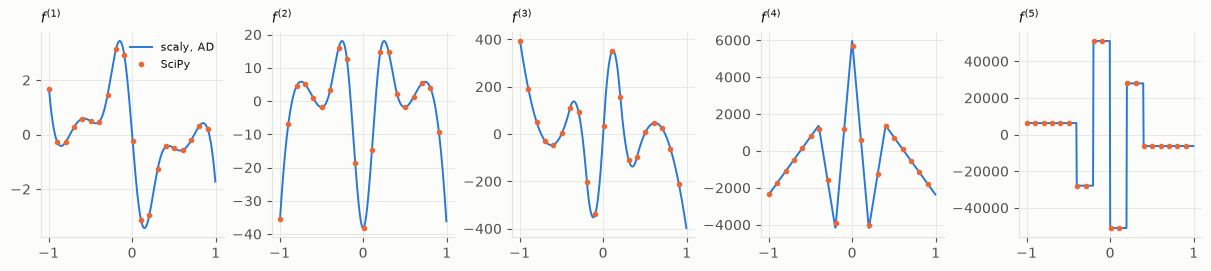

order 1: AD 6.5e-16, derivative() 1.1e-15 (relative to max |f^(1)| = 3.43)
order 2: AD 7.4e-16, derivative() 1.2e-15 (relative to max |f^(2)| = 38.2)
order 3: AD 5.0e-16, derivative() 1.4e-15 (relative to max |f^(3)| = 398)
order 4: AD 3.1e-16, derivative() 7.6e-16 (relative to max |f^(4)| = 5.95e+03)
order 5: AD 1.4e-16, derivative() 1.4e-16 (relative to max |f^(5)| = 5.1e+04)


In [6]:
quintic = fits["runge", "spline"]
scipy_quintic = si.make_interp_spline(runge_x, runge_y, k=5)
q = np.linspace(-1.0, 1.0, 401)[1:-1] + 1e-3  # off the knots, where each derivative is one-sided
derivative_rows = []
fig, axes = plt.subplots(1, 5, figsize=(12, 2.6))
for nu, ax in zip(range(1, 6), axes, strict=True):
  by_ad = evaluate(quintic, q, nu, label=f"quintic_ad{nu}")
  as_spline = evaluate(quintic.derivative(nu), q, label=f"quintic_derivative{nu}")
  ref = scipy_quintic(q, nu)
  scale = np.abs(ref).max()
  derivative_rows.append((nu, np.abs(by_ad - ref).max() / scale, np.abs(as_spline - ref).max() / scale, scale))
  ax.plot(q, by_ad, color=plotstyle.BLUE, lw=1.4)
  ax.plot(q[::20], ref[::20], "o", color=plotstyle.ORANGE, ms=3)
  ax.set_title(f"$f^{{({nu})}}$", fontsize=10)
axes[0].legend(["scaly, AD", "SciPy"], fontsize=8)
plt.show()
for nu, ad, spline, scale in derivative_rows:
  print(f"order {nu}: AD {ad:.1e}, derivative() {spline:.1e} (relative to max |f^({nu})| = {scale:.3g})")

Both routes agree with SciPy to $10^{-15}$ relative to each derivative's size, including the
fifth, which is piecewise constant and reaches $5 \times 10^4$.

## Integrals and an inverse

`integrate(a, b)` integrates the piecewise polynomial exactly. With numbers it returns a number.
With an `Expr` limit it returns an expression, which can be differentiated and compiled like any
other; its derivative with respect to the upper limit is the spline there.

`inverse()` reads a strictly monotone spline backwards. A table names the cell, then Newton's
method runs inside it, bisecting whenever a step would leave the cell. The derivative is
$dx/dy = 1/f'(x)$, supplied directly rather than by differentiating the iterations. The example
is a thermistor: a 10 kΩ NTC tabulated every 10 °C from −20 to 80 °C by the B-parameter law
($B = 3950$ K), interpolated by PCHIP (monotone data stay monotone) and read back as temperature
from resistance.

In [7]:
cubic = fits["runge", "cubic"]
exact = 0.4 * np.arctan(5.0)  # the integral of Runge's function over [-1, 1]
spline_integral = cubic.integrate(-1.0, 1.0)
scipy_integral = reference.integrate(-1.0, 1.0)
print(f"integral over [-1, 1]: spline {spline_integral:.15f}, SciPy {scipy_integral:.15f}, Runge's function {exact:.15f}")



@sc.function(sc.L("b", ()), output=sc.G("area", "d_area"), name="kinds_area")
def area(b):
  a = cubic.integrate(sc.const(-1.0), b)
  return a, sc.gradient(a, b)


b_values = np.array([-0.95, -0.3, 0.0, 0.41, 0.97])
area_error = max(abs(float(area(bv)[0]) - reference.integrate(-1.0, bv)) for bv in b_values)
ftc = max(abs(float(area(bv)[1]) - float(reference(bv))) for bv in b_values)
print(f"integral to a symbolic b: against SciPy {area_error:.1e}; its derivative in b against the spline at b {ftc:.1e}")

integral over [-1, 1]: spline 0.551967781561475, SciPy 0.551967781561475, Runge's function 0.549360306778006
integral to a symbolic b: against SciPy 1.1e-16; its derivative in b against the spline at b 1.4e-16


R(T(R)) = R to 1.3e-16 relative; dT/dR * dR/dT = 1 to 1.7e-15; T against the B-parameter law: 0.167 K at most


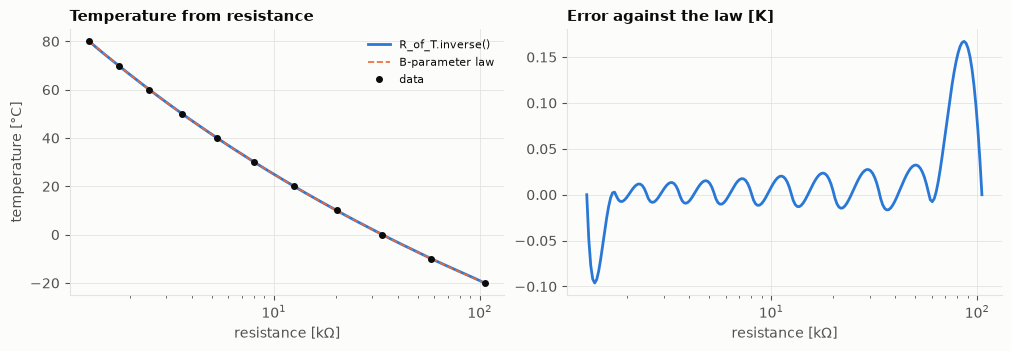

In [8]:
# A thermistor's resistance against temperature, and the temperature read back from a resistance.
T_data = np.arange(-20.0, 90.0, 10.0)  # C
R_data = 10.0 * np.exp(3950.0 * (1.0 / (T_data + 273.15) - 1.0 / 298.15))  # kOhm
R_of_T = interp.interpolant(T_data, R_data, kind="pchip", name="thermistor")
T_of_R = R_of_T.inverse()
R_query = np.geomspace(R_data[-1], R_data[0], 200)
T_back = evaluate(T_of_R, R_query, label="thermistor_inverse")
round_trip = float(np.abs(evaluate(R_of_T, T_back, label="thermistor_forward") - R_query).max() / R_query.max())
dT_dR = evaluate(T_of_R, R_query, 1, label="thermistor_inverse_slope")
slope_check = float(np.abs(dT_dR * evaluate(R_of_T, T_back, 1, label="thermistor_forward_slope") - 1.0).max())
T_exact = 1.0 / (np.log(R_query / 10.0) / 3950.0 + 1.0 / 298.15) - 273.15
print(f"R(T(R)) = R to {round_trip:.1e} relative; dT/dR * dR/dT = 1 to {slope_check:.1e}; T against the B-parameter law: {np.abs(T_back - T_exact).max():.3f} K at most")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
ax1.semilogx(R_query, T_back, color=plotstyle.BLUE, label="R_of_T.inverse()")
ax1.semilogx(R_query, T_exact, "--", color=plotstyle.ORANGE, lw=1.2, label="B-parameter law")
ax1.semilogx(R_data, T_data, "o", color=plotstyle.TEXT, ms=4, label="data")
ax1.set_xlabel("resistance [kΩ]")
ax1.set_ylabel("temperature [°C]")
ax1.set_title("Temperature from resistance")
ax1.legend(fontsize=8)
ax2.semilogx(R_query, T_back - T_exact, color=plotstyle.BLUE)
ax2.set_xlabel("resistance [kΩ]")
ax2.set_title("Error against the law [K]")
plt.show()

The cubic's integral over $[-1, 1]$ equals SciPy's to the last digit. It differs from the
integral of Runge's function itself by $2.6 \times 10^{-3}$, the interpolation error, not an
integration error. With a symbolic upper limit the integral matches SciPy to $10^{-16}$, and its
derivative is the spline at the limit, as the fundamental theorem says.

The inverse's round trip $R(T(R))$ returns $R$ to $6 \times 10^{-15}$ relative. The product of
the two slopes is 1 to $2 \times 10^{-15}$. The temperature read back differs from the
B-parameter law by at most 0.17 K, the interpolation error of 10 °C spacing where the curve bends
most, at the cold end.

## CasADi's interpolants

CasADi 3.8's `interpolant` has three of these kinds: `linear`, `bspline` (the not-a-knot
cubic) and the `smooth_linear` algorithm. Each is compared with the matching kind here, on both
data sets, inside the grid.

In [9]:
casadi_rows = []
for name, (x, y) in DATA.items():
  for method, kind, opts in (("linear", "linear", {}), ("bspline", "cubic", {}), ("bspline", "smooth_linear", {"algorithm": "smooth_linear"})):
    table = ca.interpolant(f"ca_{name}_{kind}", method, [list(x)], list(y), opts)
    theirs = np.asarray(table.map(DENSE[name].size)(DENSE[name][None, :])).reshape(-1)
    casadi_rows.append((name, kind, float(np.abs(values[name, kind] - theirs).max())))
for row in casadi_rows:
  print(f"{row[0]:6s} {row[1]:14s} max |scaly - CasADi| = {row[2]:.1e}")

runge  linear         max |scaly - CasADi| = 3.3e-16
runge  cubic          max |scaly - CasADi| = 5.6e-16
runge  smooth_linear  max |scaly - CasADi| = 3.3e-16
steps  linear         max |scaly - CasADi| = 4.4e-16
steps  cubic          max |scaly - CasADi| = 1.8e-15
steps  smooth_linear  max |scaly - CasADi| = 1.3e-15


All six agree to $2 \times 10^{-15}$. The differences between the two libraries are outside
the grid, shown above, and in which kinds exist.

## The generated C

The thermistor's inverse as one C function: temperature and $dT/dR$ from a resistance. The
tables are baked into the source, and the Newton loop is a `while` loop in C.

In [10]:
@sc.function(sc.L("R", ()), output=sc.G("T", "dT_dR"), name="thermistor_temperature")
def thermistor(R):
  T = T_of_R(R)
  return T, sc.gradient(T, R)


module = write_module(thermistor, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.1f} kB")
print("\n".join(line for line in module.header.splitlines() if line.startswith("int ")))
T_47, slope_47 = thermistor(4.7)
print(f"at 4.7 kOhm: T = {float(T_47):.2f} C, dT/dR = {float(slope_47):.2f} K/kOhm")

thermistor_temperature.c: 230 lines, 10.4 kB
int thermistor_temperature(const double** arg, double** res, int* iw, double* w, int mem);


at 4.7 kOhm: T = 43.03 C, dT/dR = -5.37 K/kOhm


The files are in `examples/generated/interp/interpolation_kinds/`.

## Checks

In [11]:
for (name, kind), err in vs_reference.items():
  assert err < 1e-12 * max(1.0, np.abs(DATA[name][1]).max()), (name, kind, err)
shape = {kind: (over, mono, smooth) for kind, over, mono, smooth, _ in shape_rows}
assert all(shape[k][0] < 1e-12 and shape[k][1] for k in ("linear", "pchip", "steffen", "nearest", "zoh"))  # no overshoot, monotone
assert shape["cubic"][0] > 0.1 and shape["akima"][0] > 0.0 and not shape["cubic"][1]  # the C2 cubic rings
assert (shape["cubic"][2], shape["spline"][2], shape["pchip"][2], shape["linear"][2], shape["nearest"][2], shape["zoh"][2]) == (2, 4, 1, 0, -1, -1)
assert extend_error < 1e-13 and np.abs(casadi_outside[~inside]).max() == 0.0
assert np.all(extrapolated["clamp"][outside < -1.0] == runge_y[0]) and np.all(extrapolated["fill"][~inside] == 0.0)
assert np.abs(extrapolated["periodic"] - evaluate(cubic, (outside + 1.0) % 2.0 - 1.0, label="wrapped")).max() < 1e-13
assert all(ad < 1e-10 and spline < 1e-10 for _, ad, spline, _ in derivative_rows)
assert abs(spline_integral - scipy_integral) < 1e-14 and area_error < 1e-14 and ftc < 1e-14
assert round_trip < 1e-13 and slope_check < 1e-12
assert all(err < 1e-12 for _, _, err in casadi_rows)
print("all 10 checks passed")

all 10 checks passed
